With the following code we want to discover possible clusters in a dataset that contains temporal series of data, in which every row corresponds to the temporal evolution of the heartbeat. The goal is to distinguish cases according to the patient's pathology.

To transport data into numpy we use a library called sktime beacause the dataset file is not in .csv format.

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from sktime.datasets import load_from_tsfile

K = 5
N_ITER = 10

x_train, y_train = load_from_tsfile(
    "ECG5000_TRAIN.ts",
    return_data_type = "numpy2d"
)

x_test, y_test = load_from_tsfile(
    "ECG5000_TEST.ts",
    return_data_type = "numpy2d"
)

print(f"Dataset shape x: {x_train.shape}")
print(f"Dataset shape y: {y_train.shape}")

Dataset shape x: (500, 140)
Dataset shape y: (500,)


In [28]:
print(y_test)

['1' '1' '1' ... '2' '2' '2']


Draw representatives.

In [29]:
rng = np.random.default_rng(seed=33)
representatives_index = rng.choice(x_train.shape[0], size=K, replace=False)
representatives = x_train[representatives_index].copy()
print(f"Extracted indexes : {representatives_index}")
print(f"Extracted representatives : {representatives}")

Extracted indexes : [189 283 435 220 415]
Extracted representatives : [[-1.7522274e+00 -3.0484714e+00 -3.2985180e+00 -3.9577832e+00
  -4.0019439e+00 -3.6621479e+00 -2.7180751e+00 -1.8179748e+00
  -1.3349230e+00 -9.5424698e-01 -5.9292414e-01 -3.6086213e-01
  -2.8308377e-01 -3.2983300e-01 -3.3953253e-01 -3.2941492e-01
  -2.4590200e-01 -2.0983401e-01 -1.8745639e-01 -1.5043406e-01
  -2.0634927e-01 -2.1112684e-01 -1.5238707e-01 -2.1736232e-01
  -1.7597796e-01 -6.1719944e-02 -7.2572645e-02 -7.3465179e-02
  -7.3250957e-02 -1.9023572e-02 -3.8230918e-02 -5.7452311e-02
  -6.0604387e-02 -8.8237017e-02 -1.1348058e-01 -7.0568076e-02
  -8.0600437e-02 -1.6064920e-01 -1.5859298e-01 -8.5383854e-02
  -1.5033508e-01 -1.0285800e-01 -1.7931779e-01 -2.0968788e-01
  -1.1698179e-01 -1.8549543e-01 -1.2906011e-01 -6.2230578e-02
  -9.0365470e-02 -3.7406655e-02 -4.6401093e-02 -8.4115476e-02
  -1.4286312e-01 -8.7404160e-02 -9.1972141e-02 -7.4852495e-02
  -1.2349185e-01 -1.8603788e-01 -2.5145662e-01 -2.1182340e-01


Cicle to obtain the clusters.

In [30]:
def dist(diff):
    return np.sqrt(np.sum(diff**2, axis=1))

for num_iterations in range(N_ITER):
    old_representatives = representatives.copy()
    labels = np.zeros(x_train.shape[0], dtype=int)
    for i in range(x_train.shape[0]):
        labels[i] = np.argmin(dist(representatives-x_train[i]))

    for k in range(K):
        cluster_points = x_train[labels==k]
        if len(cluster_points) > 0:
            representatives[k] = np.mean(cluster_points, axis=0)
    if np.all(old_representatives == representatives):
        print(f"Convergence achieved after {num_iterations} iterations!!!")

Plotting the graphs of each cluster to display the differnce betweem them. We can see that the obtained results are not optimal due to the impossibility of the Euclidean mean to catch the temporal shifting of signals.

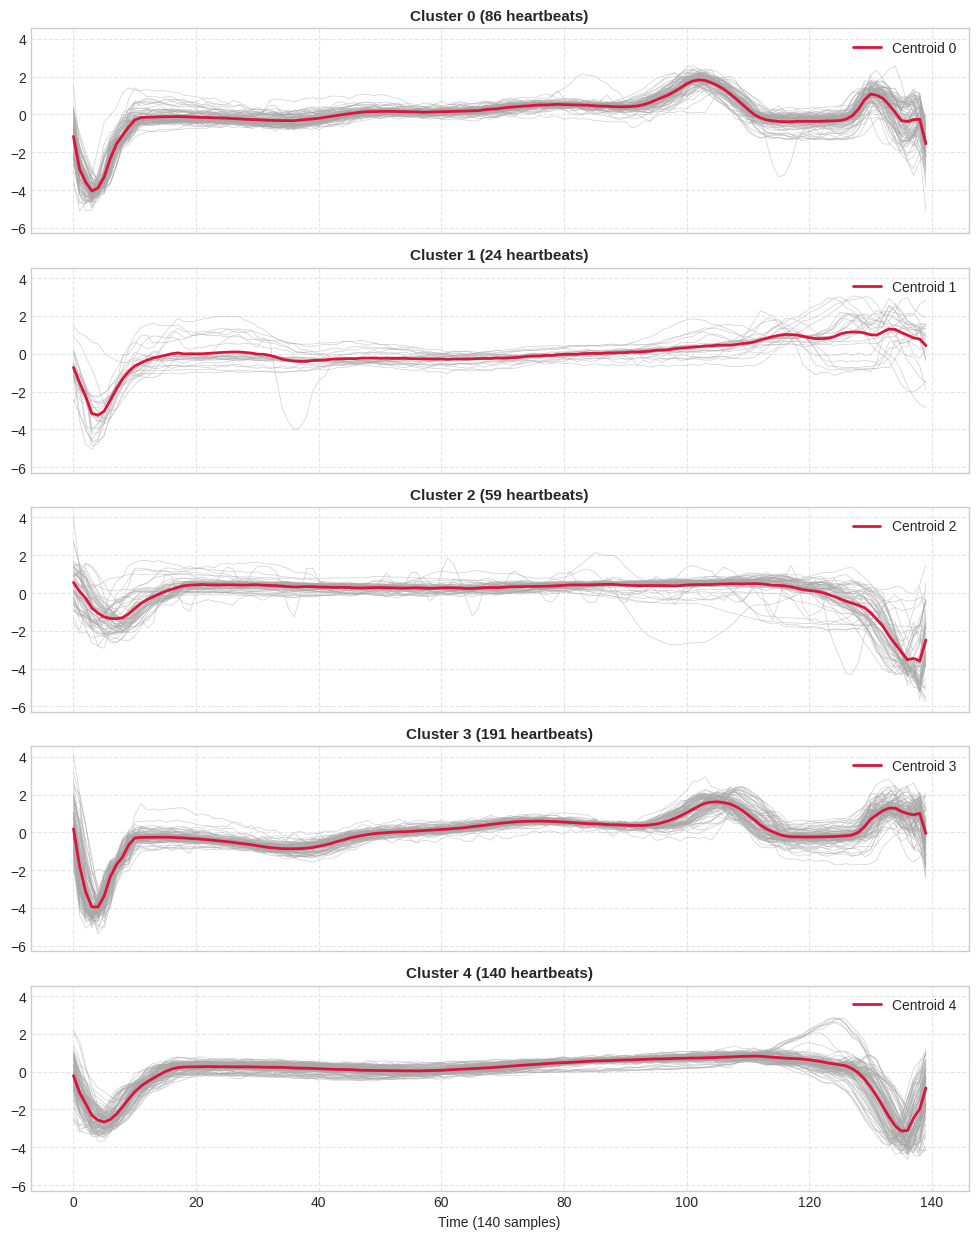

In [31]:
fig, axes = plt.subplots(K, 1, figsize=(10, 2.5 * K), sharex=True, sharey=True)
MAX_CURVES = 100
for k in range(K):
    cluster_signals = x_train[labels == k]
    ax = axes[k]
    for signal in cluster_signals[:MAX_CURVES]:
        ax.plot(signal, color='darkgray', alpha=0.55, linewidth=0.5)
    
    ax.plot(representatives[k], color='crimson', linewidth=2, label=f'Centroid {k}')
    ax.set_title(f"Cluster {k} ({len(cluster_signals)} heartbeats)", fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

plt.xlabel("Time (140 samples)")
plt.tight_layout()
plt.show()

Using sklearn to analayze the results. The value returned is clipped between -1 and +1.

In [32]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

sil = silhouette_score(x_train, labels)
cal = calinski_harabasz_score(x_train, labels)
print(f"Silhouette Global Score : {sil:.3f}")
print(f"Calinski Harabasz Global Score : {cal:.3f}")

Silhouette Global Score : 0.215
Calinski Harabasz Global Score : 201.634


Using testset to evaluate the results.

In [33]:
from sklearn.metrics import adjusted_rand_score

def kmeans_testing():
    test_labels = np.zeros(x_test.shape[0], dtype=int)
    for i in range(x_test.shape[0]):
        test_labels[i] = np.argmin(dist(representatives-x_test[i]))
    return test_labels

ari_score = adjusted_rand_score(y_test, kmeans_testing())
print(f"Clustering quality on Test Set (ARI): {ari_score:.3f}")

Clustering quality on Test Set (ARI): 0.497


In [34]:
np.savez("risultati_kmeans.npz", x_train=x_train, labels=labels, representatives=representatives)

Now we can try to process data with another algorithm in order to catch a more precise cluseter identification. For this reason we use the Dynamic Time Warping (DTW). In the STEP 1 we assign every time-series to a representative based on the fastdtw value that returns the dtw distance between the representative and the series.
In the STEP 2 we have the main difference between the K-means and DTW, in facts, we use the old centroids of each cluster and identify the similarity with the other series of the cluster. In this way we obtain a path that tracks the associations in time between the old centroid and the other series and using this we move the centroid towards the series that have a greater similarity with the old centroid. This dynamic barycenter technique is called DBA (DTW Barycenter Averaging).

In [35]:
from fastdtw import fastdtw

N, L = x_train.shape

rng = np.random.default_rng(seed=34)
representatives = x_train[rng.choice(N, K, replace=False)]

labels = np.zeros(N, dtype=int)

max_iter = 10

def dba_update_custom(cluster_points, old_representative):
    centroid_sum = np.zeros(L)
    centroid_count = np.zeros(L)

    for point in cluster_points:
        _, path = fastdtw(old_representative, point, dist=lambda x, y: (x - y)**2)
        for t_old_centroid, t_point in path:
            centroid_sum[t_old_centroid] += point[t_point]
            centroid_count[t_old_centroid] += 1
    
    centroid_count[centroid_count==0] = 1
    
    return centroid_sum/centroid_count


for iteration in range(max_iter):
    # STEP 1 : assignment
    new_labels = np.zeros(N, dtype=int)
    for i in range(N):
        distances = []
        for k in range(K):
            dist, _ = fastdtw(x_train[i], representatives[k], dist=lambda x, y: (x - y)**2)
            distances.append(dist)
        new_labels[i] = np.argmin(distances)
    
    # convergence verification
    if np.all(new_labels==labels):
        break
    labels = new_labels.copy()

    # STEP 2 : recalculation of representatives (DBA)
    for k in range(K):
        cluster_points = x_train[labels==k]
        if len(cluster_points) > 0:
            representatives[k] = dba_update_custom(cluster_points, representatives[k])
    print(f"Iteration {iteration+1}/{max_iter} completed.")

Iteration 1/10 completed.
Iteration 2/10 completed.
Iteration 3/10 completed.
Iteration 4/10 completed.
Iteration 5/10 completed.
Iteration 6/10 completed.
Iteration 7/10 completed.
Iteration 8/10 completed.
Iteration 9/10 completed.
Iteration 10/10 completed.


The following graphs do not represent a correct visualization of the results and just shows the differnce with the k-means.

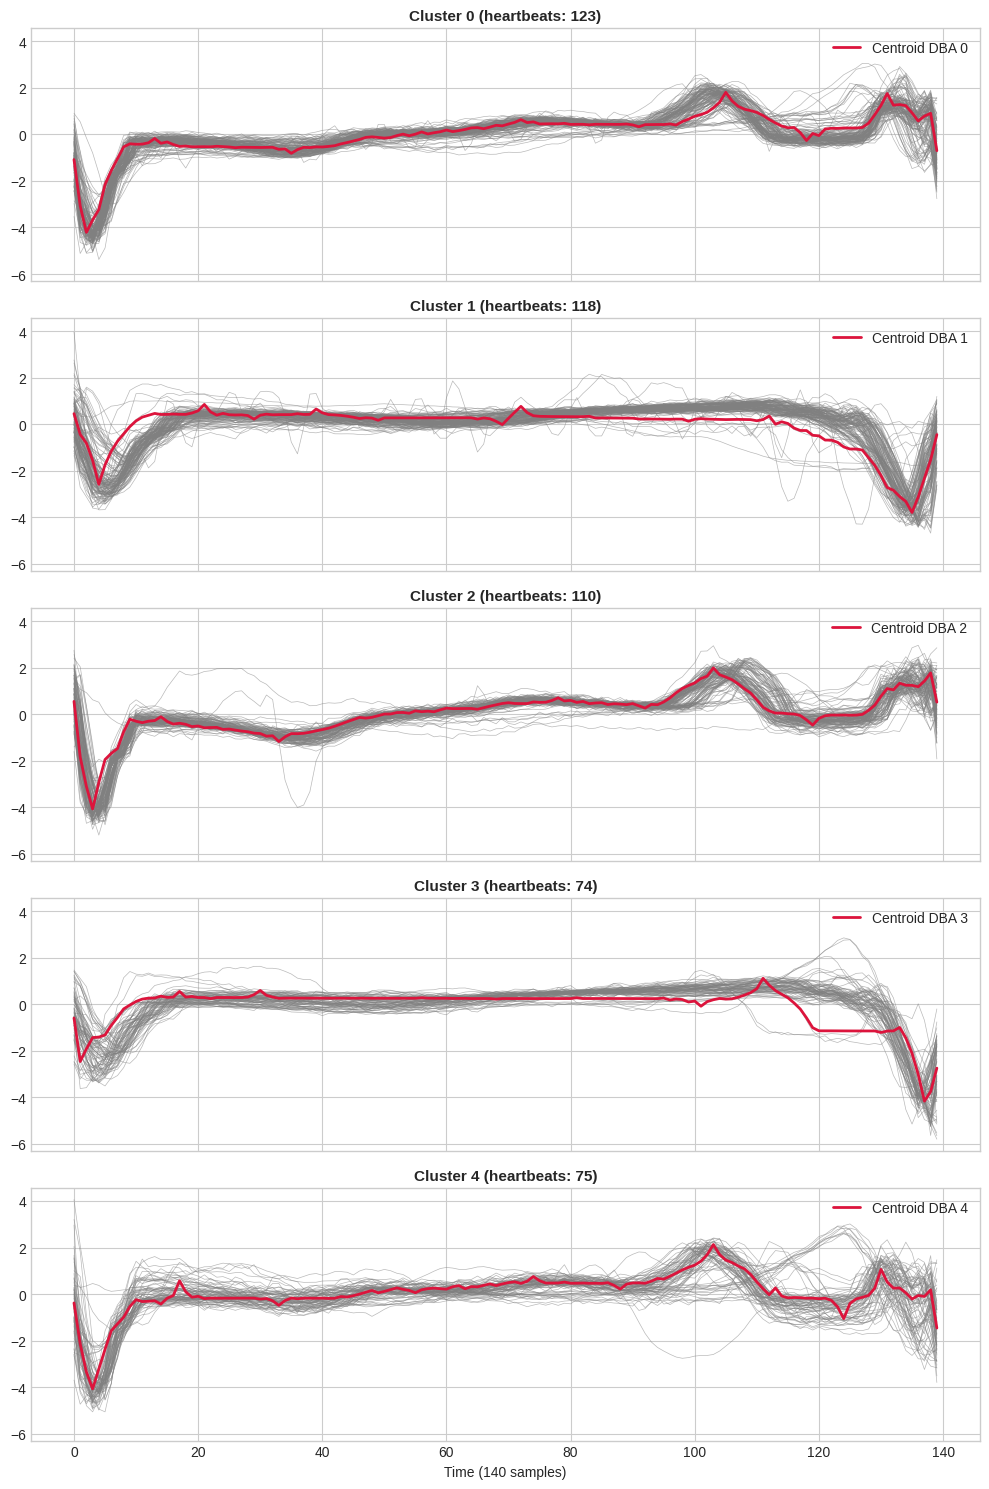

In [36]:
plt.style.use('seaborn-v0_8-whitegrid') # se dà errore usa 'default'

fig, axes = plt.subplots(K, 1, figsize=(10, 3 * K), sharex=True, sharey=True)

for k in range(K):
    cluster_signals = x_train[labels == k]
    for signal in cluster_signals:
        axes[k].plot(signal, color='gray', alpha=0.55, linewidth=0.5)
    axes[k].plot(representatives[k], color='crimson', linewidth=2, label=f'Centroid DBA {k}')
    axes[k].set_title(f'Cluster {k} (heartbeats: {len(cluster_signals)})', fontsize=11, fontweight='bold')
    axes[k].legend(loc='upper right')

axes[-1].set_xlabel('Time (140 samples)')
plt.tight_layout()
plt.show()

Here is a way to see the path associations between the centroid and a single series taken from it.

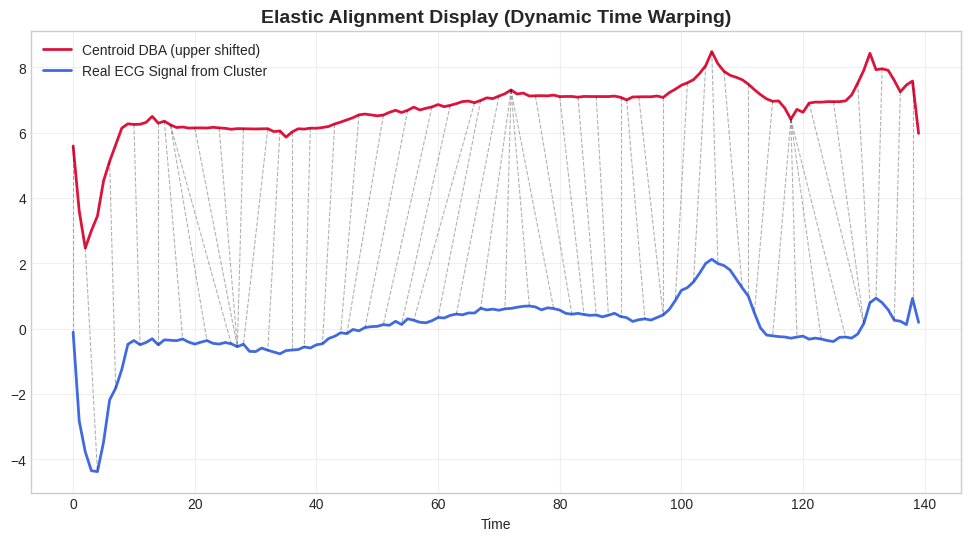

In [37]:
# we take just the first cluster and the first signal of teh cluster
target_cluster = 0
signals_cluster = x_train[labels == target_cluster]

if len(signals_cluster) > 0:
    segnale_esempio = signals_cluster[0]
    centroide_esempio = representatives[target_cluster]

    _, path = fastdtw(centroide_esempio, segnale_esempio, dist=lambda x, y: (x - y)**2)

    plt.figure(figsize=(12, 6))
    
    offset = np.max(centroide_esempio) - np.min(segnale_esempio) + 0.5
    
    plt.plot(centroide_esempio + offset, color='crimson', linewidth=2, label='Centroid DBA (upper shifted)')
    plt.plot(segnale_esempio, color='royalblue', linewidth=2, label='Real ECG Signal from Cluster')

    for t_bary, t_sig in path[::4]:
        plt.plot([t_bary, t_sig], [centroide_esempio[t_bary] + offset, segnale_esempio[t_sig]], 
                 color='black', linestyle='--', alpha=0.3, linewidth=0.8)

    plt.title("Elastic Alignment Display (Dynamic Time Warping)", fontsize=14, fontweight='bold')
    plt.xlabel("Time")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print(f"The cluster {target_cluster} is empty.")

This script calculates the Silhouette Score for a DTW algorithm

In [38]:
from sklearn.metrics import silhouette_score

n_eval = min(300, len(x_train))
X_eval = x_train[:n_eval]
labels_eval = labels[:n_eval]

dtw_dist_matrix = np.zeros((n_eval, n_eval))
for i in range(n_eval):
    for j in range(i+1, n_eval):
        d, _ = fastdtw(X_eval[i].ravel(), X_eval[j].ravel(), dist=lambda x, y: (x - y)**2)
        dtw_dist_matrix[i, j] = d
        dtw_dist_matrix[j, i] = d

true_dtw_silhouette = silhouette_score(dtw_dist_matrix, labels_eval, metric='precomputed')
print(f"Silhouette with DTW metric: {true_dtw_silhouette:.3f}")

Silhouette with DTW metric: 0.252


In [39]:
def dtw_testing():
    test_labels = np.zeros(x_test.shape[0], dtype=int)
    for i in range(x_test.shape[0]):
        distances = []
        for k in range(K):
            dist, _ = fastdtw(x_test[i], representatives[k], dist=lambda x, y: (x - y)**2)
            distances.append(dist)
        test_labels[i] = np.argmin(distances)
    return test_labels

ari_score = adjusted_rand_score(y_test, dtw_testing())
print(f"Clustering quality on Test Set (ARI): {ari_score:.3f}")

Clustering quality on Test Set (ARI): 0.329


In [41]:

np.savez("risultati_DTW_euclidean.npz", x_train=x_train, labels=labels, representatives=representatives)